<h1 style="color:blue; text-align:center; font-weight:700">Handwritten Digit Recognition using Logistic Regression</h1>

---

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
digits = load_digits()

In [2]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [3]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

<Figure size 640x480 with 0 Axes>

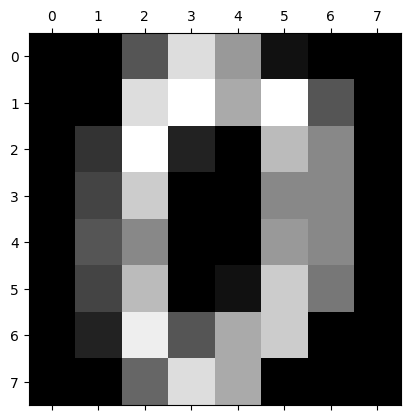

In [4]:
plt.gray()
plt.matshow(digits.images[0])
plt.show()

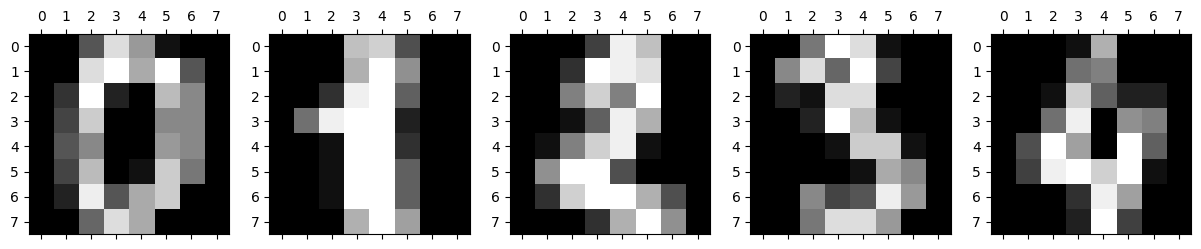

In [5]:
# Create a single figure with subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
plt.gray()  # Set the colormap to gray

# Plot each image in its respective subplot
for i in range(5):
    axes[i].matshow(digits.images[i])

plt.show()

In [6]:
print(digits.target_names[:5])

[0 1 2 3 4]


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [8]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.1,random_state=42)

In [9]:
print(len(X_train), len(X_test))

1617 180


In [10]:
model = LogisticRegression(max_iter=1000)

In [11]:
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [12]:
model.score(X_test, y_test)*100

97.22222222222221

---

### Taking a random digit:

<Figure size 640x480 with 0 Axes>

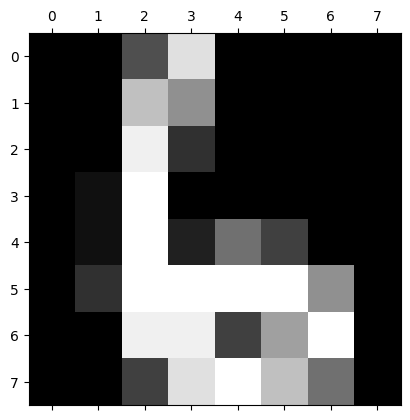

In [13]:
plt.gray()
plt.matshow(digits.images[67])
plt.show()

In [14]:
print(digits.target[67])

6


In [15]:
model.predict([digits.data[67]])

array([6])

In [16]:
y_predicted = model.predict(X_test)

## ***So how do we understand that where our model is failing???***

- ***for this we have `Confusion Matrix`***

<h3 style="color:red;font-weight:700;">Confusion Matrix</h3>

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[17,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 11,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 17,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 16,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 24,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 22,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 19,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 18,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  8,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  1, 23]])

Text(95.72222222222221, 0.5, 'Truth')

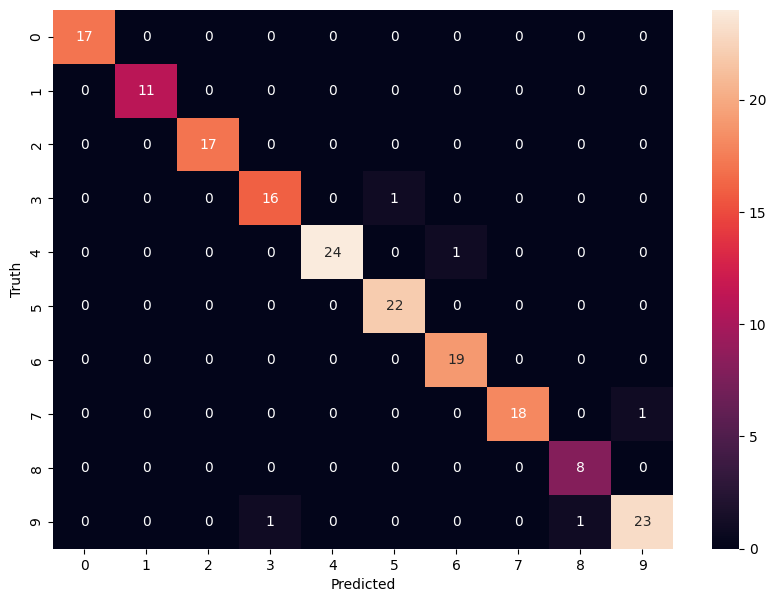

In [18]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

- ***Where there is other than 0 in the black area that's when our model predicted wrong***
- ***And Confusion Matrix is a nice way of visualizing the model's accuracy***